# Load and Explore Data

In [7]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

CSV_DIR = "data/df.csv"

df = pd.read_csv(CSV_DIR)

df = df.dropna(subset=['text'])

print(df.shape)

X = df['text']

# 0 -> ham
# 1 -> phish
# 2 -> spam
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# only words:
# - atleast in two documents to prevent overfitting
# - not in more than 70% of the documents, reduce "corpus-specific" words
text_clf = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=2, max_df=0.7)), 
    ('clf', MultinomialNB())
])

text_clf.fit(X_train, y_train)

predictions = text_clf.predict(X_test)

print(classification_report(y_test, predictions))

(365446, 2)
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     33705
           1       0.67      0.83      0.74      8627
           2       0.93      0.84      0.88     30758

    accuracy                           0.90     73090
   macro avg       0.85      0.88      0.86     73090
weighted avg       0.91      0.90      0.90     73090



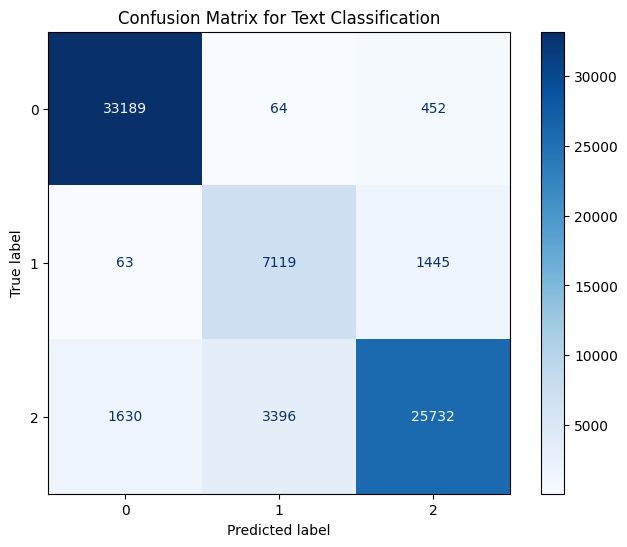

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(8, 6))

# Use from_estimator to predict and plot in one go
cmd = ConfusionMatrixDisplay.from_estimator(
    text_clf, 
    X_test, 
    y_test, 
    display_labels=text_clf.classes_,
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title('Confusion Matrix for Text Classification')
plt.show()